# Multi-Asset Portfolio Performance, Risk & Attribution

## Introduction

This report has been constructed to evaluate the performance, risk management, and attribution of the super fund. The fund currently invests in five distinct sleeves, particularly Australian Equities, International Equities, Bonds, Real Estate, and Private Equity / Venture Capital. Although this report will analyse the performance of the fund in its entirety, it will also seek to assess the managers' performance in their respective sleeves relatives to their benchmarks. Using monthly data, the evaluations will be composed against a benchmark using Tactical Asset Allocation (TAA) weights, and the report will consist of APRA-inspired risk checks to ensure compliancy. Moreover, performance will be measured further using a Brinson-style attribution test. All the analysis seen in this report was completed using Python modules for a reproducible code. 

## 1.0 Executive Summary

The multi-asset fund's portfolio delivered strong performance in all five sleeves over the analysis period - outperforming all benchmarks. International Equities was the largest contributor to fund outperformance, demonstrating an annualised return of 15.57% compared to the benchmark of 13.94%, including the highest Sharpe ratio of 1.05 - suggesting superior risk-adjusted returns. Real Estate and PE/VC also outperformed their benchmarks, generating returns of 10.84% against 8.03%, and 10.24% against 9.38% respectively. However, Real Estate held the largest volatility of 18.72% and the deepest manager drawdown of -28.69%, yet given the outperforming result this may simply imply a struggling real estate market due to uncertainty. Moreover, Australian Equities outperformed the benchmark by approimately 1%, though its Sharpe ratio was only 0.27 suggesting not very high risk-adjusted returns. As expected, bonds produced the lowest return of 3.02% out of the sleeves, yet delivered a significant tracking error of 0.94% and strongest information ratio of 1.21%, meaning it was the closest to the benchmark and was highly-consistent. 

Through the Brinson-Style Attribution analysis it was determined that in total, the fund generated an active return of 0.1631% per month above the benchmark indicator. Distinctively, the allocation effect accounted for 0.0616% and the selection effect 0.1012% of that active monthly return. This suggests that manager skill (selection effect) was the dominant source of the funds return, and in the current analysis period the managers have outperformed the market. 

Finally, APRA-inspired checks showed that in all three selected scenarios, the managers passed. Specifically, Long-Run Return vs Objective (CPI + 3%), Annualised Volatility vs Risk Limit (12%), and Maximum Drawdown vs Threshold (-25%). With each check using the industry average thresholds for clarity. 

In conclusion, the fund has performed strongly in this analysis period, considering the complete dominance and outperformance of the benchmark sleeves, an outweighing selevtion effect, and successful adherance to important APRA checks. 

## 2.0 Data and Methodology 

### 2.1 Data

The analysis uses monthly return data that has been cleaned to remove any abnormalities, missing values, or incorrect indices. This monthly return data encompasses both, manager performance and the benchmark metrics for the five sleeves: Australian Equities (AUS EQ), International Equities (INTL EQ), Bonds, Real Estate (RE), and Private Equity/Venture Capital (PE/VC). In which, the benchmarks reflect industry-standard proxies such as, the S&P/ASX 200 Index, MSCI World ex-Australia index, a Bloomberg AUS-Bond proxy, A-REIT proxy, and a stylethised-synthetic benchmark for PE/VC. Additionally, for the purpose of produce Sharpe Ratios, a risk-free rate data set is include too. 

Throughout the calculations two sets of weights are used to separate the current positioning of the fund and the strategic, long-term aim. These weights are called the Strategic Asset Allocation (SAA) and Tactical Asset Allocation (TAA) weights and are held constant throughout the analysis period as the following values:

| Asset Class              | TAA Weight | SAA Weight |
|--------------------------|------------|------------|
| Australian Equities      | 35%        | 40%        |
| International Equities   | 35%        | 30%        |
| Bonds                    | 15%        | 20%        |
| Real Estate              | 5%         | 5%         |
| PE/VC                    | 10%        | 5%         |

### 2.2 Methodology 

Performance metrics were calculated using monthly returns and were annualised geometrically to capture the compound growth rate through the formula: $$R_{\text{ann}} = \left(\prod(1 + r_t)\right)^{\frac{12}{n}} - 1$$ Alternatively, annualised valuatility was derived by scaling the monthly standard deviation by $\sqrt{12}$. Through this, the Sharpe Ratio was calculated using the ratio of excess annualised return over the annualised risk-free rate to annualised volatility, measuring return per total unit of risk. To measure divergence and consistency levels, tracking error was defined as the annualised standard deviation of monthly active returns (manager minus benchmarks), and the information ratio was calculated from the ratio of active annualised returns to tracking error. Lastly, aaximum drawdown was found as the largest peak-to-trough decline in cumulative wealth over the analysis period.  

APRA-inspired risk checks were applied to the total fund return, constructed using TAA weights and manager returns each month (since current compliance requires current figures). To complete this risk check, three simplified APRA-inspired checks were adopted, in particular Long-Run Return vs Objective (CPI + 3%), Annualised Volatility vs Risk Limit (12%), and Maximum Drawdown vs Threshold (-25%). To simulate the "bear" case results of the fund, two simulations were developed — an equity crash scenario (-20% applied to AUS EQ and INTL EQ returns) and a bond yield spike scenario (+150bps, implying approximately -6% on bonds assuming a duration of 4 years, with spillover effects across other asset classes). This test was made to observe the resilience of the fund in the given environments. 

Lastly, Brinson-Style Attribution analysis was conducted to evaluate the managers' selection performance. It was performed monthly and then aggregated to the full analysis period averages. The composite benchmark return was constructed using SAA weights and monthly returns. Ultimately, the allocation effects were calculated using the following: $$(w_{P,i} - w_{B,i}) \times R_{B,i}$$ Selection effects: $$w_{B,i} \times (R_{P,i} - R_{B,i})$$ Then the total active return for each sleeve as the sum of its allocation and selection effects. 

### Set-Up of Data and Pathways 

Below is the uploading of the data for the analysis procedures. 

In [15]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print(sys.version)
print("pandas:", pd.__version__, "numpy:", np.__version__)
pd.set_option("display.float_format", "{:.4f}".format)

3.13.2 (v3.13.2:4f8bb3947cf, Feb  4 2025, 11:51:10) [Clang 15.0.0 (clang-1500.3.9.4)]
pandas: 2.2.3 numpy: 2.2.2


Below is the establishment of pathways, to extract the data from alternative modules. 

In [4]:
# Base paths
BASE      = "/Users/masonplummer/Desktop/2026/Semester 1/FINM3422/Project 2 - Asset Management Assessment /FINM3422-Group-8-Task-2/data/"
BM_PATH   = BASE + "benchmarks/"
MGR_PATH  = BASE + "managers/"

# Load rf and SAA
df_rf  = pd.read_csv(BASE + "rf_monthly.csv", parse_dates=["Date"]).set_index("Date")
df_saa = pd.read_csv(BASE + "saa_weight.csv", index_col="Sleeve")

Below are some sanity checks and initial cleaning for the datasets. 

In [5]:
SLEEVES = ["aus_eq", "intl_eq", "bonds", "re", "pevc"]

df_benchmarks = pd.concat([
    pd.read_csv(BM_PATH + f"{s}_bm.csv", parse_dates=["Date"])
      .set_index("Date")
      .rename(columns={"Return": s})
    for s in SLEEVES
], axis=1)

df_managers = pd.concat([
    pd.read_csv(MGR_PATH + f"{s}_mgr.csv", parse_dates=["Date"])
      .set_index("Date")
      .rename(columns={"Return": s})
    for s in SLEEVES
], axis=1)

# Sanity checks
print("N/A in bm", df_benchmarks.isna().sum().sum())
print("N/A in mgr", df_managers.isna().sum().sum())
print("aligned dates?", df_benchmarks.index.equals(df_managers.index))
print("Monotonic dates?", df_benchmarks.index.is_monotonic_increasing)
display(df_managers.head())
display(df_benchmarks.head())

N/A in bm 0
N/A in mgr 0
aligned dates? True
Monotonic dates? True


,aus_eq,intl_eq,bonds,re,pevc
Date,,,,,
2016-01-31,-0.0364,0.0083,0.0148,-0.0099,-0.0117
2016-02-29,0.0461,0.0232,0.0049,0.0332,-0.0315
2016-03-31,0.0377,-0.0149,0.0016,0.0319,0.0098
2016-04-30,0.0382,0.0108,-0.0012,0.0466,-0.0547
2016-05-31,-0.0316,0.0752,0.0209,0.0489,0.0013


,aus_eq,intl_eq,bonds,re,pevc
Date,,,,,
2016-01-31,-0.0249,0.0032,0.0143,-0.0002,-0.0119
2016-02-29,0.0414,0.0062,0.0087,0.0312,-0.0336
2016-03-31,0.0333,-0.0083,-0.0013,0.0271,0.0146
2016-04-30,0.0241,0.0144,-0.0051,0.0198,-0.0585
2016-05-31,-0.0270,0.0743,0.0206,0.0358,0.0152


## 3.0 Analysis 

## 3.1 Performance and Risk Analysis 

As previously mentioned, this section involves key metrics used in portfolio analysis. Specifically, annualised returns, annualised volatility, Sharpe Ratio, tracking erros, information ratio, and maximum drawdown. A combination of the metrics provide a good foundation for the analysis of portfolio risk and its performance over a given period of time. The following formulae were used in the process of analysing the performance and risk of the portfolio: 

**Annualised Returns**

$$R_{\text{ann}} = \left(\prod(1 + r_t)\right)^{\frac{12}{n}} - 1$$

**Annualised Volatility**

$$\sigma_{\text{ann}} = \sigma_{\text{monthly}} \times \sqrt{12}$$

**Sharpe Ratio**

$$\text{Sharpe} = \frac{R_{\text{ann}} - RF_{\text{ann}}}{\sigma_{\text{ann}}}$$

**Tracking Error**

$$TE = \text{std}(r_P - r_B) \times \sqrt{12}$$

**Information Ratio**

$$IR = \frac{R_p - R_b}{TE}$$

**Maximum Drawdown**

$$MDD = \min_t \left(\frac{W_t - \max(W)}{\max(W)}\right)$$

In order to process these results, a performance module detailing the Python code used to rewrite these functions - given the data - was created. The following code is the extraction of those modules. 

In [6]:
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))  # Extracts module from src directory

from performance import all_sleeves_summary

summary = all_sleeves_summary(df_managers, df_benchmarks, df_rf)

Now, the following are tabular representations of the results derived from the performance and risk analysis metrics above:

In [13]:
pct_rows = [
    "Annualised Return (Manager)",
    "Annualised Return (Benchmark)",
    "Annualised Volatility",
    "Tracking Error",
    "Maximum Drawdown (Manager)",
    "Maximum Drawdown (Benchmark)",
]
ratio_rows = ["Sharpe Ratio", "Information Ratio"]

print("Table 1: Performance & Risk Summary (%)")
display(summary.loc[pct_rows].style.format("{:.4f}%"))

print("Table 2: Ratios")
display(summary.loc[ratio_rows].style.format("{:.4f}"))

Table 1: Performance & Risk Summary (%)


,aus_eq,intl_eq,bonds,re,pevc
Annualised Return (Manager),0.0691%,0.1557%,0.0302%,0.1084%,0.1024%
Annualised Return (Benchmark),0.0588%,0.1394%,0.0189%,0.0803%,0.0938%
Annualised Volatility,0.1416%,0.1196%,0.0446%,0.1872%,0.1086%
Tracking Error,0.0440%,0.0257%,0.0094%,0.0710%,0.0208%
Maximum Drawdown (Manager),-0.2463%,-0.1649%,-0.1135%,-0.2869%,-0.1162%
Maximum Drawdown (Benchmark),-0.2765%,-0.1642%,-0.1394%,-0.3740%,-0.1195%


Table 2: Ratios


,aus_eq,intl_eq,bonds,re,pevc
Sharpe Ratio,0.2733,1.0477,-0.0048,0.4165,0.6632
Information Ratio,0.2336,0.6353,1.2077,0.3945,0.4120


In [12]:
return_diff = summary.loc["Annualised Return (Manager)"] - summary.loc["Annualised Return (Benchmark)"]
print("Difference between Manager and Benchmark Annualised Returns:")
display(return_diff)

Difference between Manager and Benchmark Annualised Returns:


aus_eq    0.0103
intl_eq   0.0163
bonds     0.0113
re        0.0280
pevc      0.0086
dtype: float64

It is evident that across all five sleeves managers outperformed the respective benchmarks, demonstrating broad-based skill levels at the management position. For example, the difference in annualised returns for all sleeves were positive, with notable outperformers including, Real Estate with a 2.80% improvement to the benchmark, International Equities with a 1.63% improvement, and Bonds with a 1.13% improvement. 

For Australian Equities, the manager delivered an annualised return of 6.91%, which outperformed the benchmark of 5.88%. However, this result came alongside relatively high levels of volatility of 14.16% - the second highest among all sleeves, in which resulted in a moderate Sharpe Ratio of 0.27. The information ratio of 0.23 suggests that despite the manager added value, there was a lack in consistency. This tracking error of 4.40% supports this claim. Although, on the risk side, this manager limited drawdowns better than the benchmark (-24.63% vs -27.65%), which is a positive outcome, suggesting some degree of downside protection during adverse market conditions. Overall, the Australian Equity Manager has done a successful job given these factors. 

International Equities sleeve in the fund was extremely effective in generating returns, constructing an annualised return of 15.57% against a benchmark return of 13.94%, an outperformance of 163 basis points. Additionally, this was achieved with the lowest annualised volatility among the equity sleeves (14.16%), and a slight tracking error of 2.57%. This sleeve also posted the highest Sharpe Ratio of 1.05 and an information ratio 0.64. Typically, a Sharpe Ratio above 1 is a strong indicator of proficient risk-adjusted performance in institutional portfolio management. Despite the marginally worse drawdon management than the benchmark, given the maximum drawdowns for the manager and benchmark of -16.49% and -16.42% respectively, the INTL EQ sleeve represents the most compelling case of manager skill in the portfolio.

The Bonds sleeve produced an annualised return of 3.02% which was an improvement from the benchmark of 1.89%. Exectantly, the Bonds sleeve maintained the lowest amount of annualised volatility of all sleeves, around 4.46% and a tracking error of 0.94%. Combining this with an information ratio of 1.21, the Bonds manager demonstrated disciplined benchmark-relative management and generated active return with exceptional consistency relative to the risk taken. The manager also contained drawdowns better than the benchmark (-11.35% vs -13.94%), reinforcing the sleeve's defensive characteristics.

The Real Estate sleeve came with the highest annualised return differential out of any sleeve, approximately 2.80% with a total generated annualised return of 10.84%. However, it also generated the highest annualised volatility, with 18.72% and the widest tracking error of 7.10%, suggesting the manager took on considerable active risk to generate this return. The Sharpe Ratio of 0.42 and information ratio of 0.39 are moderate and indicate that the risk-adjusted efficiency of that outperformance is lower than sleeves such as International Equity or PE/VC. Moreover, the manager's maximum drawdown was 28.69% which although seems high on the surface, was substantially better than the benchmark of -37.40%. Given the illiquid and cyclical nature of real estate as an asset class, the manager's ability to limit drawdowns significantly below the benchmark during stressed periods is a particularly valuable outcome.

Lastly, the PE/VC sleeve delivered an annualised return of 10.24% against a benchmark of 9.38%, outperforming by 0.86%. The sleeve exhibited a moderate level volatility with annualised volatility of 10.86% and tracking error of 2.08%. This manager produced a Sharpe Ratio of 0.66 and information ratio of 0.41, suggesting the portfolio generated a moderately good level of return relative to the total risk taken. The manager's drawdown profile of -11.62% was in line with the benchmark of -11.95%, implying small downside differentiation but also stable risk management. Utlimately, this manager's performance was relatively moderate but still positive and in line with the funds objectives. 

Collectively, this is a positive result for the fund as all managers' performances were positive, and in line with the objectives of a superfund. 

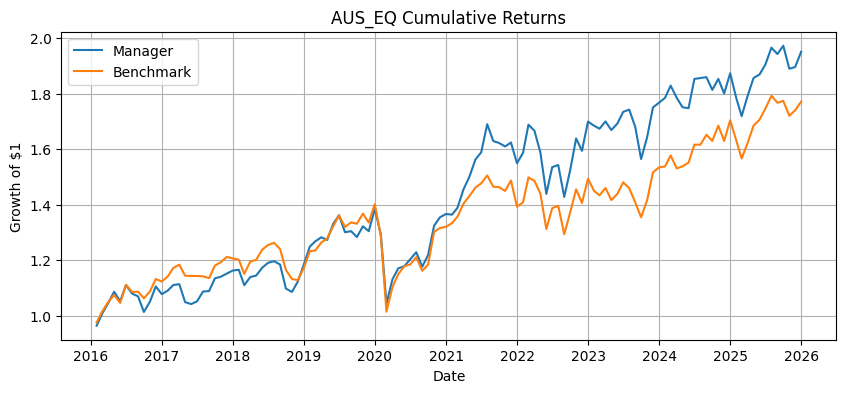

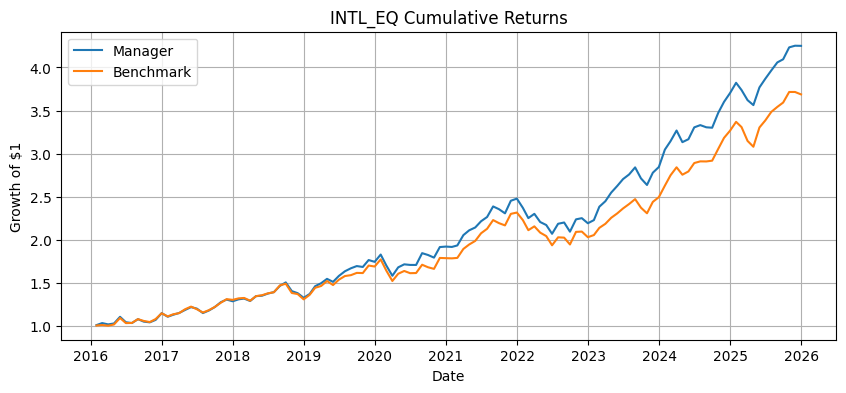

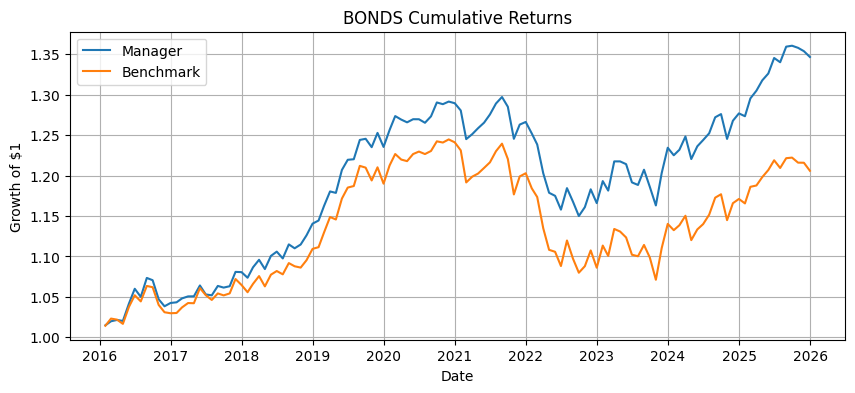

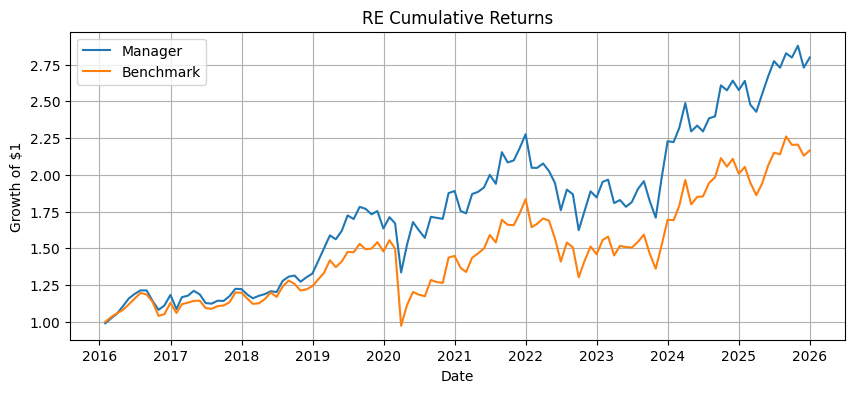

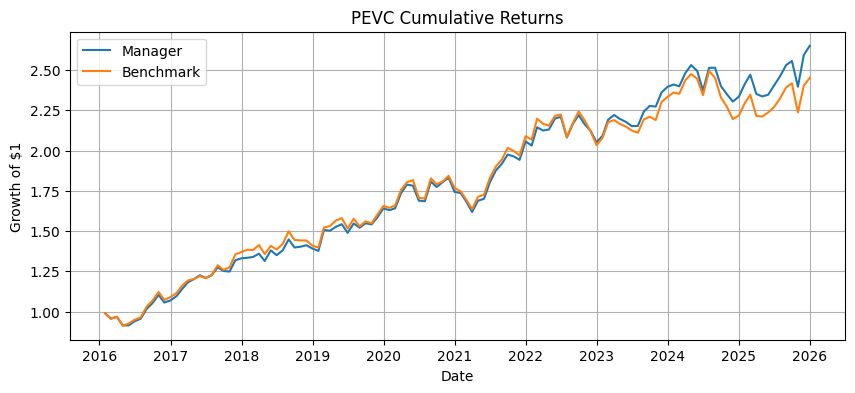

In [16]:
for sleeve in df_managers.columns:
    wealth_mgr = (1 + df_managers[sleeve]).cumprod()
    wealth_bm  = (1 + df_benchmarks[sleeve]).cumprod()
    plt.figure(figsize=(10, 4))
    plt.plot(wealth_mgr, label="Manager")
    plt.plot(wealth_bm, label="Benchmark")
    plt.title(sleeve.upper() + " Cumulative Returns")
    plt.xlabel("Date")
    plt.ylabel("Growth of $1")
    plt.legend()
    plt.grid(True)
    plt.show()